# 2026 World Cup: Knockout Matchup Probabilities

All possible knockout matchups enriched with Elo ratings and climate classifications. 100,000 correct-bracket simulations.


## 1. Setup

In [8]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import Patch
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.05)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

ml = pd.read_csv('../data/2026_matchup_list_enriched.csv').sort_values('Probability', ascending=False)
elo = pd.read_csv('../data/elo_current_2026.csv').set_index('Team')['Elo_Current']

climate_clashes = ml[ml['Is_Climate_Clash'] == 1].sort_values('Probability', ascending=False)

print(f'Total matchups: {len(ml)}')
print(f'Climate clashes (warm vs cool): {len(climate_clashes)}')

Total matchups: 1024
Climate clashes (warm vs cool): 475


## 2. Full Enriched Matchup List

In [9]:
import pandas as pd
pd.set_option('display.max_rows', None)

ml_display = ml.copy()
ml_display['Prob %'] = (ml_display['Probability'] * 100).round(2)
ml_display = ml_display[['Team_A', 'Team_B', 'Prob %', 'Elo_A', 'Elo_B', 'Elo_Diff',
                          'Warm_A', 'Warm_B', 'Koppen_A', 'Koppen_B',
                          'Climate_Zone_A', 'Climate_Zone_B', 'Is_Climate_Clash',
                          'Warm_Team', 'Cool_Team']]
ml_display.index = range(1, len(ml_display) + 1)
ml_display


,Team_A,Team_B,Prob %,Elo_A,Elo_B,Elo_Diff,Warm_A,Warm_B,Koppen_A,Koppen_B,Climate_Zone_A,Climate_Zone_B,Is_Climate_Clash,Warm_Team,Cool_Team
1,Argentina,Uruguay,43.51,2190.0,1986.0,204.0,1,1,Cfa,Cfa,Temperate,Temperate,0,NaN,NaN
2,Argentina,Spain,32.86,2190.0,2216.0,-26.0,1,1,Cfa,Csa,Temperate,Temperate,0,NaN,NaN
3,Ecuador,France,30.01,2033.0,2160.0,-127.0,1,0,Af,Cfb,Tropical,Temperate,1,Ecuador,France
4,Brazil,Netherlands,29.45,2081.0,2006.0,75.0,1,0,Am,Cfb,Tropical,Temperate,1,Brazil,Netherlands
5,France,Germany,28.97,2160.0,2032.0,128.0,0,0,Cfb,Cfb,Temperate,Temperate,0,NaN,NaN
6,Brazil,Japan,26.45,2081.0,2008.0,73.0,1,1,Am,Cfa,Tropical,Temperate,0,NaN,NaN
7,Austria,Spain,24.57,1929.0,2216.0,-287.0,0,1,Dfb,Csa,Continental,Temperate,1,Spain,Austria
8,Germany,Norway,23.24,2032.0,1994.0,38.0,0,0,Cfb,Dfc,Temperate,Continental,0,NaN,NaN
9,Algeria,Spain,22.85,1885.0,2216.0,-331.0,1,1,BWh,Csa,Arid,Temperate,0,NaN,NaN
10,Portugal,Spain,22.66,2049.0,2216.0,-167.0,1,1,Csa,Csa,Temperate,Temperate,0,NaN,NaN


## 3. Climate-Sensitive Matchups Only

In [10]:
climate_display = climate_clashes.copy()
climate_display['Prob %'] = (climate_display['Probability'] * 100).round(2)
climate_display = climate_display[['Warm_Team', 'Cool_Team', 'Prob %', 'Elo_Diff',
                                    'Koppen_A', 'Koppen_B', 'Climate_Zone_A', 'Climate_Zone_B']]
climate_display.index = range(1, len(climate_display) + 1)
print(f'{len(climate_display)} warm-vs-cool matchups')
climate_display


475 warm-vs-cool matchups


,Warm_Team,Cool_Team,Prob %,Elo_Diff,Koppen_A,Koppen_B,Climate_Zone_A,Climate_Zone_B
1,Ecuador,France,30.01,-127.0,Af,Cfb,Tropical,Temperate
2,Brazil,Netherlands,29.45,75.0,Am,Cfb,Tropical,Temperate
3,Spain,Austria,24.57,-287.0,Dfb,Csa,Continental,Temperate
4,Turkey,Belgium,22.07,4.0,Cfb,Csa,Temperate,Temperate
5,Ecuador,Norway,21.73,39.0,Af,Dfc,Tropical,Continental
6,Morocco,Netherlands,21.66,-18.0,Csa,Cfb,Temperate,Temperate
7,Portugal,England,20.16,34.0,Cfb,Csa,Temperate,Temperate
8,Colombia,England,19.97,0.0,Af,Cfb,Tropical,Temperate
9,Colombia,Switzerland,19.87,93.0,Af,Cfb,Tropical,Temperate
10,Portugal,Croatia,18.77,-70.0,Cfb,Csa,Temperate,Temperate


## 4. Top Climate Clashes by Probability

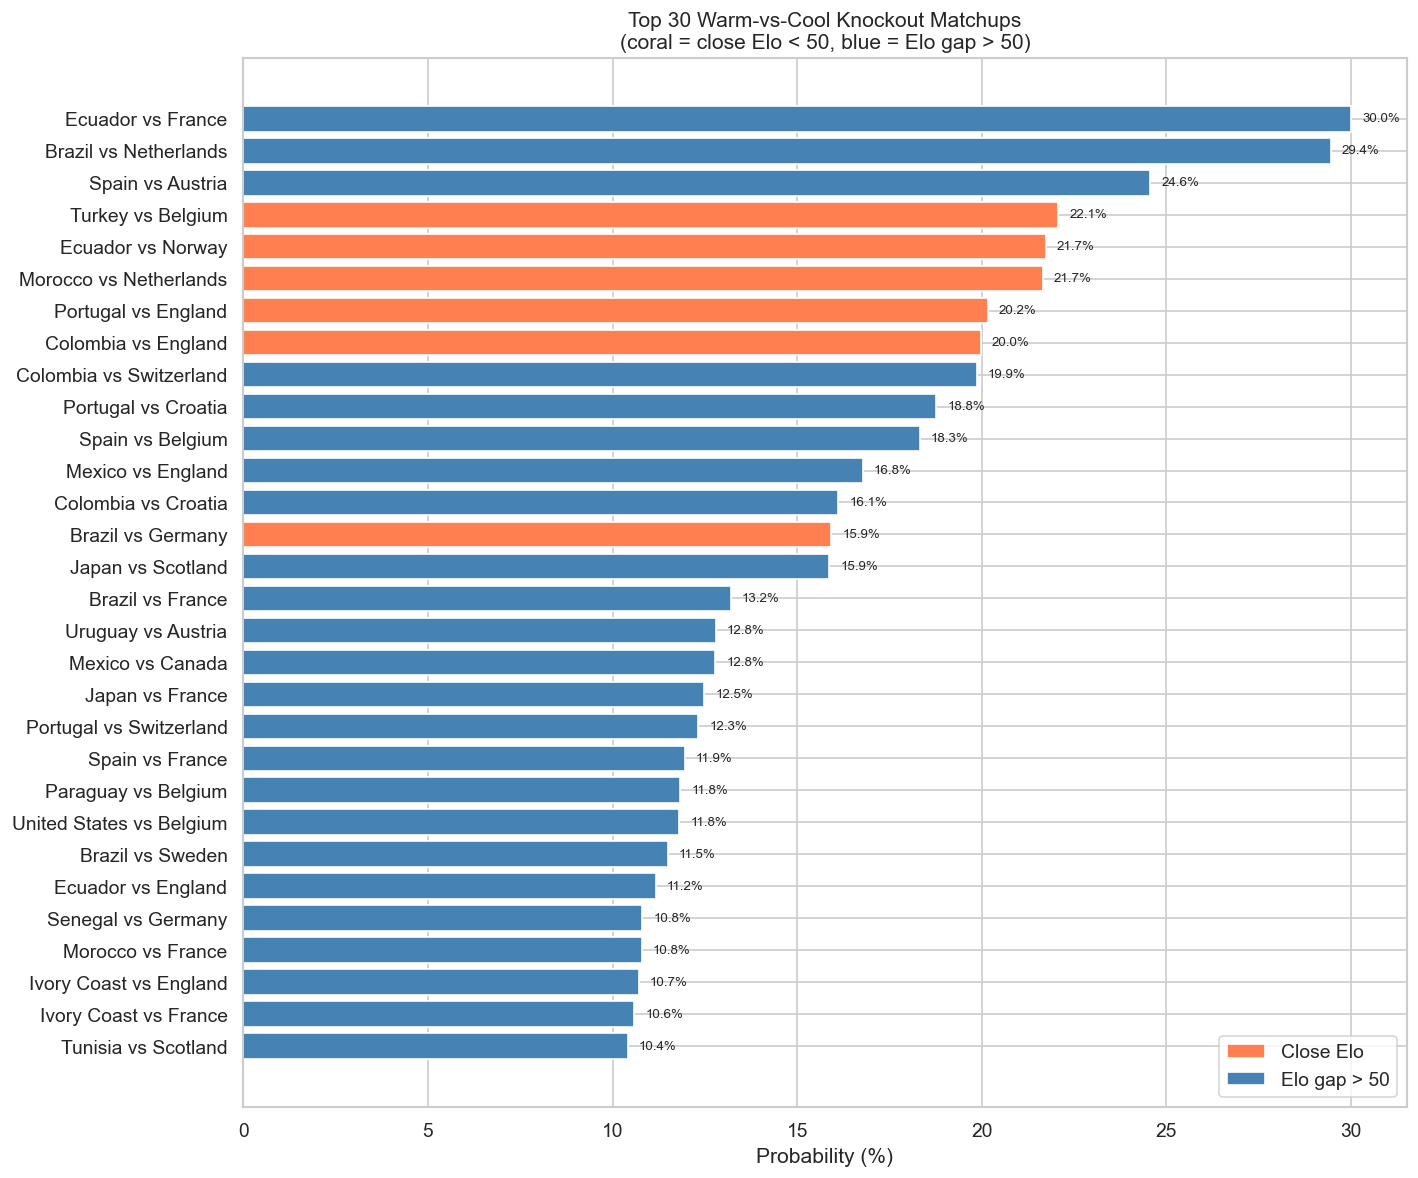

In [11]:
top = climate_clashes.head(30).sort_values('Probability')

fig, ax = plt.subplots(figsize=(12, 10))
labels = [row.Warm_Team + ' vs ' + row.Cool_Team for _, row in top.iterrows()]
colors = ['coral' if abs(row.Elo_Diff) < 50 else 'steelblue' for _, row in top.iterrows()]
ax.barh(labels, top['Probability'] * 100, color=colors, edgecolor='white')

for i, (_, row) in enumerate(top.iterrows()):
    ax.text(row.Probability * 100 + 0.3, i, f'{row.Probability*100:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Probability (%)')
ax.set_title('Top 30 Warm-vs-Cool Knockout Matchups\n(coral = close Elo < 50, blue = Elo gap > 50)')
ax.legend(handles=[Patch(facecolor='coral', label='Close Elo'), Patch(facecolor='steelblue', label='Elo gap > 50')])
plt.tight_layout()

## 5. Warm vs Cool Matchup Matrix

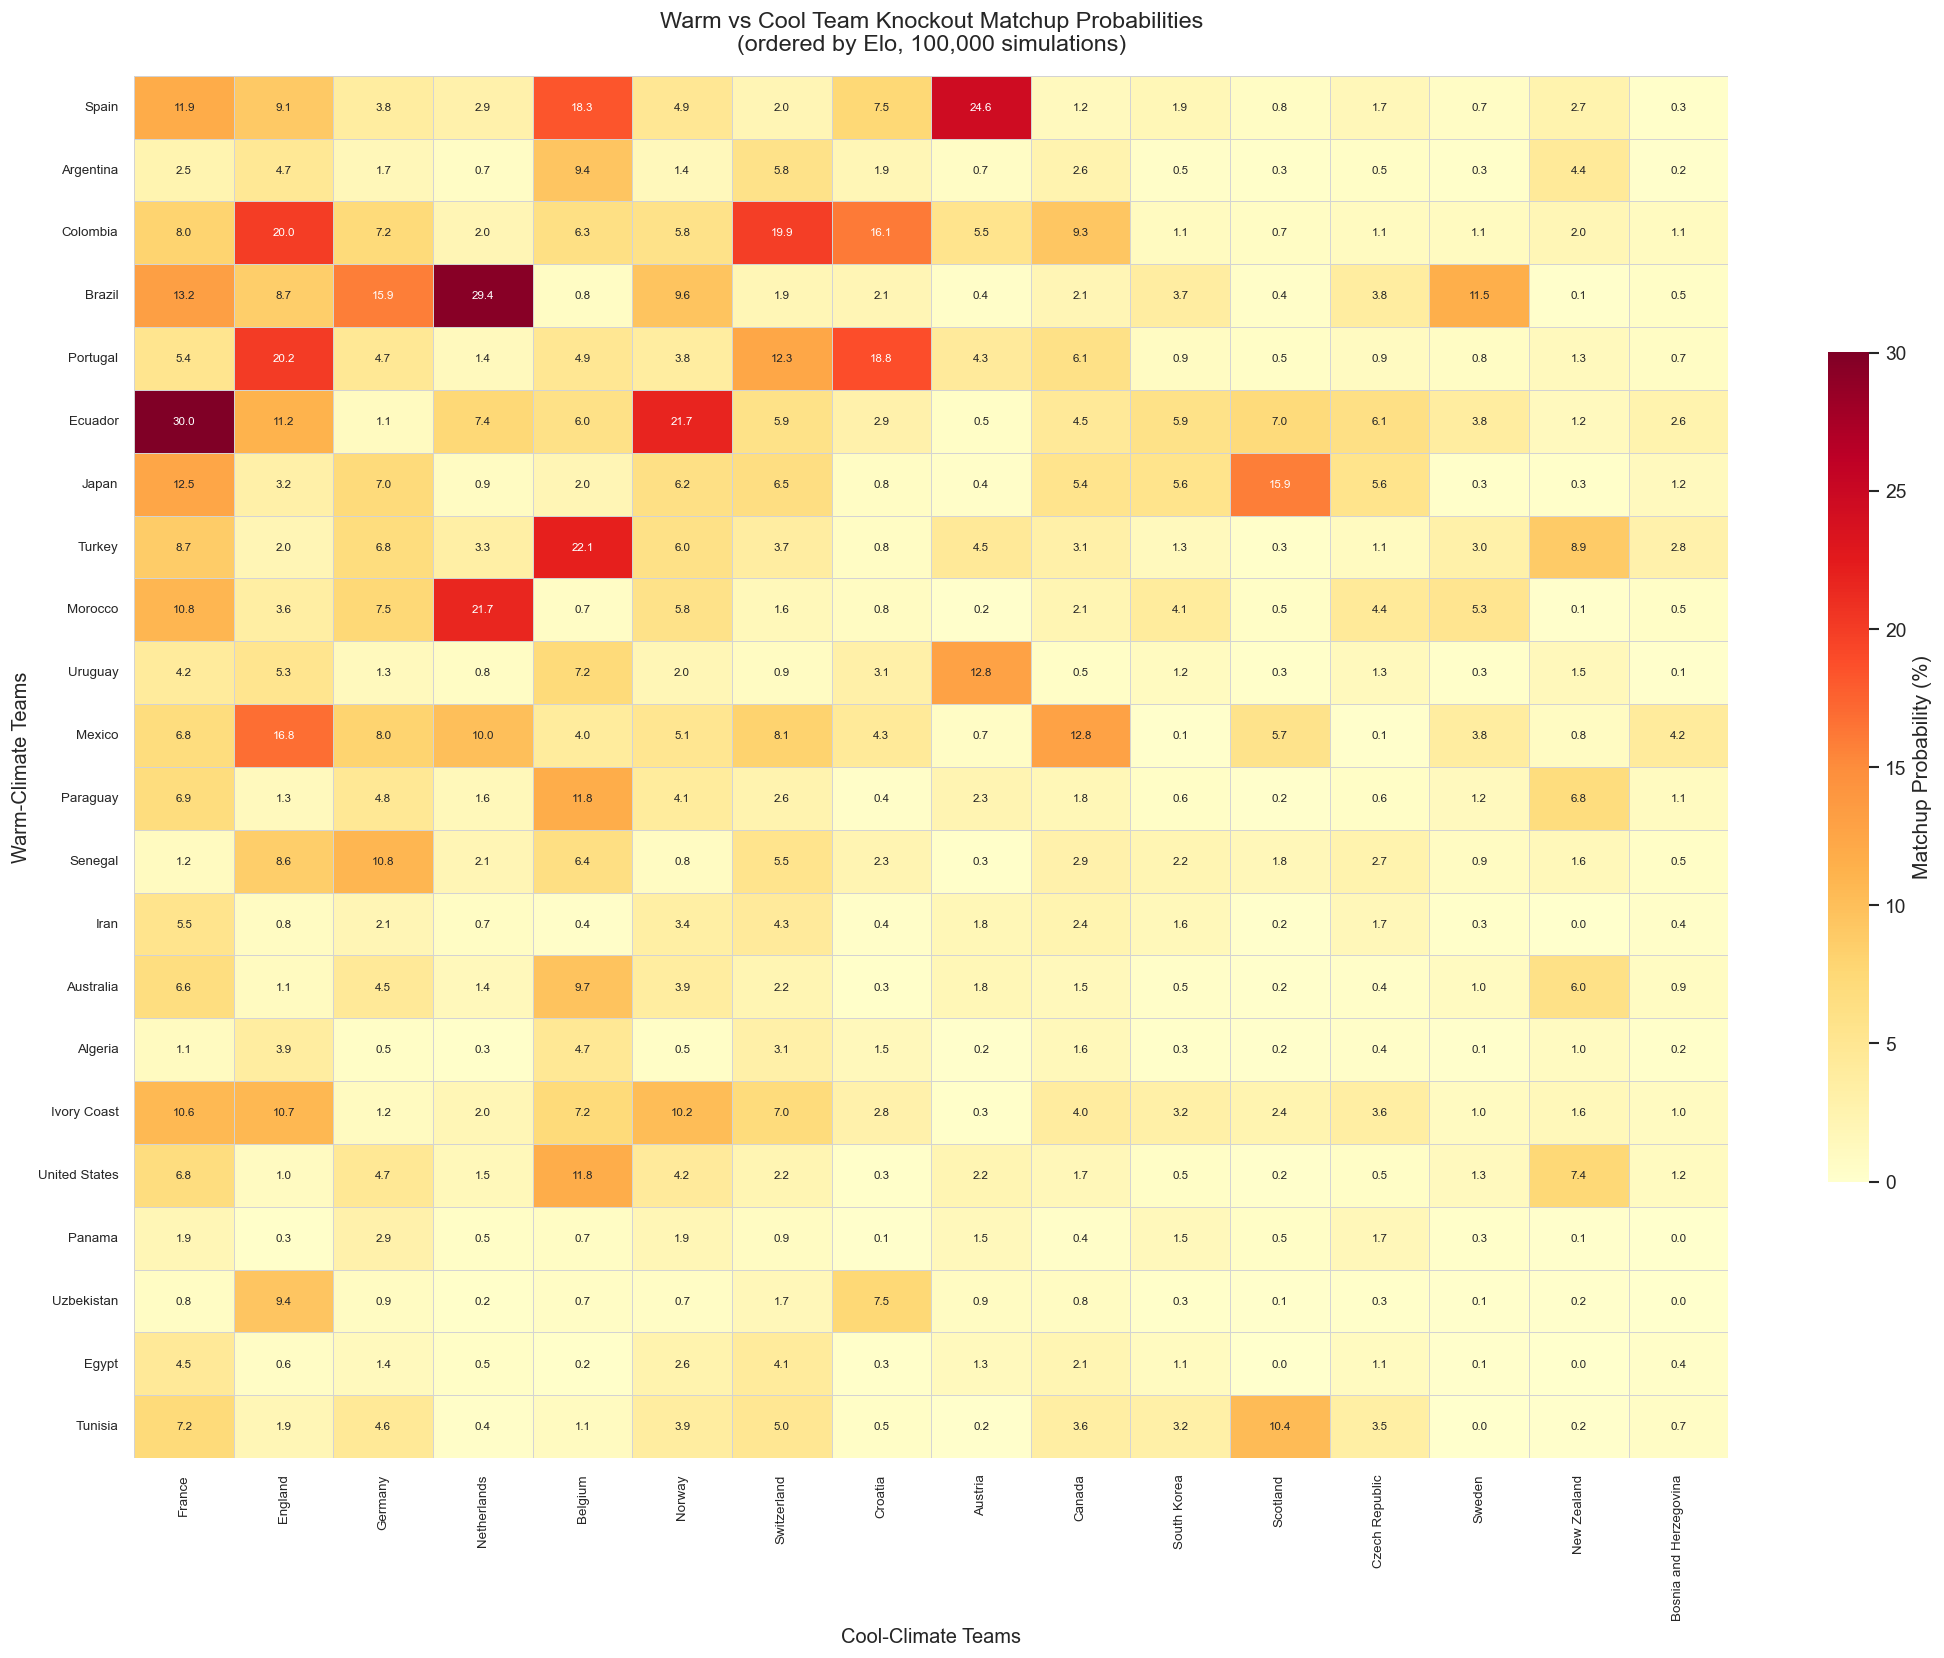

In [12]:
warm_teams = sorted(climate_clashes['Warm_Team'].unique(), key=lambda t: elo.get(t, 0), reverse=True)
cool_teams = sorted(climate_clashes['Cool_Team'].unique(), key=lambda t: elo.get(t, 0), reverse=True)

matrix = pd.DataFrame(0.0, index=warm_teams, columns=cool_teams)
for _, r in climate_clashes.iterrows():
    w, c = r.Warm_Team, r.Cool_Team
    if w in matrix.index and c in matrix.columns:
        matrix.loc[w, c] = max(matrix.loc[w, c], r.Probability * 100)

top_w = warm_teams[:22]
top_c = cool_teams[:22]
plot_mat = matrix.loc[top_w, top_c]
plot_mat = plot_mat.loc[(plot_mat > 0).any(axis=1), (plot_mat > 0).any(axis=0)]

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(plot_mat, ax=ax, cmap='YlOrRd', vmin=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Matchup Probability (%)', 'shrink': 0.6},
            linewidths=0.3, linecolor='lightgray',
            xticklabels=True, yticklabels=True, annot_kws={'fontsize': 7})
ax.set_title('Warm vs Cool Team Knockout Matchup Probabilities\n(ordered by Elo, 100,000 simulations)', fontsize=14, pad=15)
ax.set_xlabel('Cool-Climate Teams', fontsize=12)
ax.set_ylabel('Warm-Climate Teams', fontsize=12)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()

## 6. Elo Difference Distribution

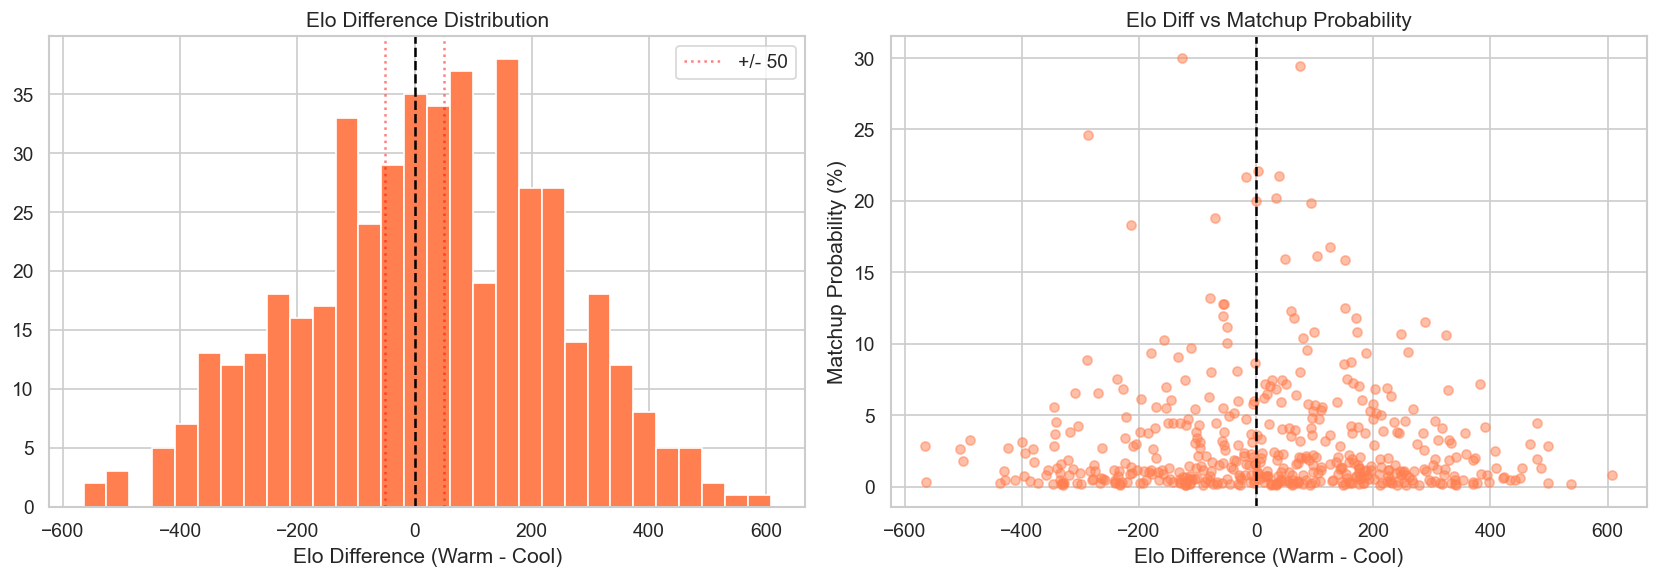

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(climate_clashes['Elo_Diff'], bins=30, color='coral', edgecolor='white')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].axvline(x=50, color='red', linestyle=':', alpha=0.5, label='+/- 50')
axes[0].axvline(x=-50, color='red', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Elo Difference (Warm - Cool)')
axes[0].set_title('Elo Difference Distribution')
axes[0].legend()

axes[1].scatter(climate_clashes['Elo_Diff'], climate_clashes['Probability'] * 100, c='coral', alpha=0.5, s=30)
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Elo Difference (Warm - Cool)')
axes[1].set_ylabel('Matchup Probability (%)')
axes[1].set_title('Elo Diff vs Matchup Probability')
plt.tight_layout()

## 7. Summary

In [14]:
print('MATCHUP ANALYSIS SUMMARY')
print('=' * 55)
print(f'Total knockout matchups: {len(ml)}')
print(f'Warm-vs-cool clashes: {len(climate_clashes)} ({len(climate_clashes)/len(ml)*100:.0f}%)')
print(f'Same-climate matchups: {len(ml) - len(climate_clashes)}')
print()
close = climate_clashes[climate_clashes['Elo_Diff'].abs() < 50]
print(f'Close Elo clashes (< 50 pts): {len(close)}')
print()

top5 = climate_clashes.head(5)
print('Top 5 most likely warm-vs-cool matchups:')
for _, r in top5.iterrows():
    fav = r.Warm_Team if r.Elo_Diff > 0 else r.Cool_Team
    gap = abs(r.Elo_Diff)
    pct = r.Probability * 100
    print(f'  {r.Warm_Team} vs {r.Cool_Team}: {pct:.1f}% (fav: {fav}, gap: {gap:.0f})')
print()

warm_facing = Counter()
for _, r in climate_clashes.iterrows():
    warm_facing[r.Warm_Team] += r.Probability
print('Warm teams most exposed to cool opponents:')
for team, prob in warm_facing.most_common(5):
    print(f'  {team:<22} total {prob*100:.1f}%')
print()

cool_facing = Counter()
for _, r in climate_clashes.iterrows():
    cool_facing[r.Cool_Team] += r.Probability
print('Cool teams most exposed to warm opponents:')
for team, prob in cool_facing.most_common(5):
    print(f'  {team:<22} total {prob*100:.1f}%')

MATCHUP ANALYSIS SUMMARY
Total knockout matchups: 1024
Warm-vs-cool clashes: 475 (46%)
Same-climate matchups: 549

Close Elo clashes (< 50 pts): 83

Top 5 most likely warm-vs-cool matchups:
  Ecuador vs France: 30.0% (fav: France, gap: 127)
  Brazil vs Netherlands: 29.4% (fav: Brazil, gap: 75)
  Spain vs Austria: 24.6% (fav: Austria, gap: 287)
  Turkey vs Belgium: 22.1% (fav: Turkey, gap: 4)
  Ecuador vs Norway: 21.7% (fav: Ecuador, gap: 39)

Warm teams most exposed to cool opponents:
  Ecuador                total 118.0%
  Colombia               total 107.2%
  Brazil                 total 104.0%
  Spain                  total 94.2%
  Mexico                 total 91.5%

Cool teams most exposed to warm opponents:
  France                 total 181.2%
  England                total 170.6%
  Belgium                total 156.3%
  Switzerland            total 120.8%
  Norway                 total 118.1%
